In [1]:
import sys 
sys.path.append('..')
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os
from src.explore import check
data_dir = '../data/raw'

In [2]:
from pathlib import Path
import numpy as np
from netCDF4 import Dataset

def get_bt(nc_path):
    ds = Dataset(nc_path)
    fk1 = ds.variables['planck_fk1'][:]
    fk2 = ds.variables['planck_fk2'][:]
    bc1 = ds.variables['planck_bc1'][:]
    bc2 = ds.variables['planck_bc2'][:]
    rad = ds.variables['Rad'][:]
    ds.close()
    bt = (fk2 / np.log(fk1 / rad + 1) - bc1) / bc2
    return np.array(bt, dtype=np.float32)

def variance_map(bt, window=256, stride=64):
    H, W = bt.shape
    bt_clean = bt.copy()
    bt_clean[bt_clean > 320] = np.nan
    bt_clean[bt_clean < 150] = np.nan
    
    rows = range(200, H - window - 200, stride)
    cols = range(200, W - window - 200, stride)
    vmap = np.zeros((len(rows), len(cols)))
    for i, r in enumerate(rows):
        for j, c in enumerate(cols):
            patch = bt_clean[r:r+window, c:c+window]
            valid = np.sum(~np.isnan(patch))
            if valid > 0.8 * window * window:
                vmap[i, j] = np.nanvar(patch)
    return vmap

files = sorted(Path('../data/raw').glob('*.nc'))

avg_vmap = None
for f in files:
    try:
        bt = get_bt(f)
        vmap = variance_map(bt)
        avg_vmap = vmap if avg_vmap is None else avg_vmap + vmap
    except:
        print(f"skipping {f.name}")

avg_vmap /= len(files)

best_idx = np.unravel_index(np.argmax(avg_vmap), avg_vmap.shape)
stride = 64
row_offset = 200
col_offset = 200
row_start = row_offset + best_idx[0] * stride
col_start = col_offset + best_idx[1] * stride
print(f"Best crop: ROW_START={row_start}, ROW_END={row_start+256}")
print(f"           COL_START={col_start}, COL_END={col_start+256}")

Best crop: ROW_START=392, ROW_END=648
           COL_START=1160, COL_END=1416


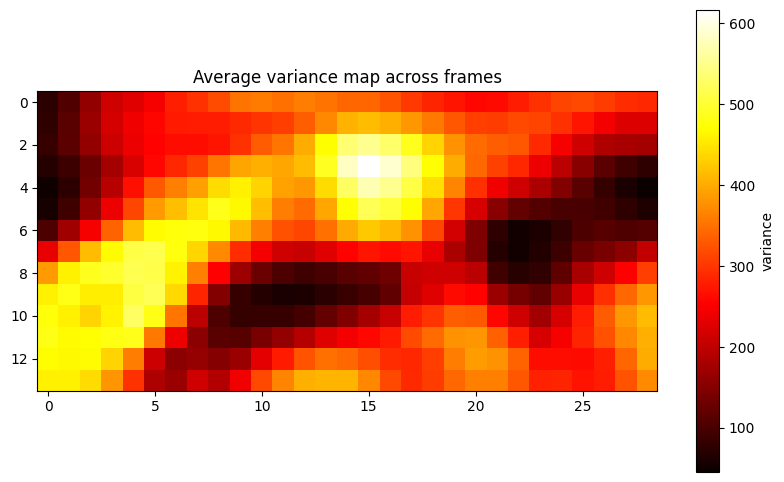

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.imshow(avg_vmap, cmap='hot')
plt.colorbar(label='variance')
plt.title('Average variance map across frames')
plt.savefig('vmap.png')

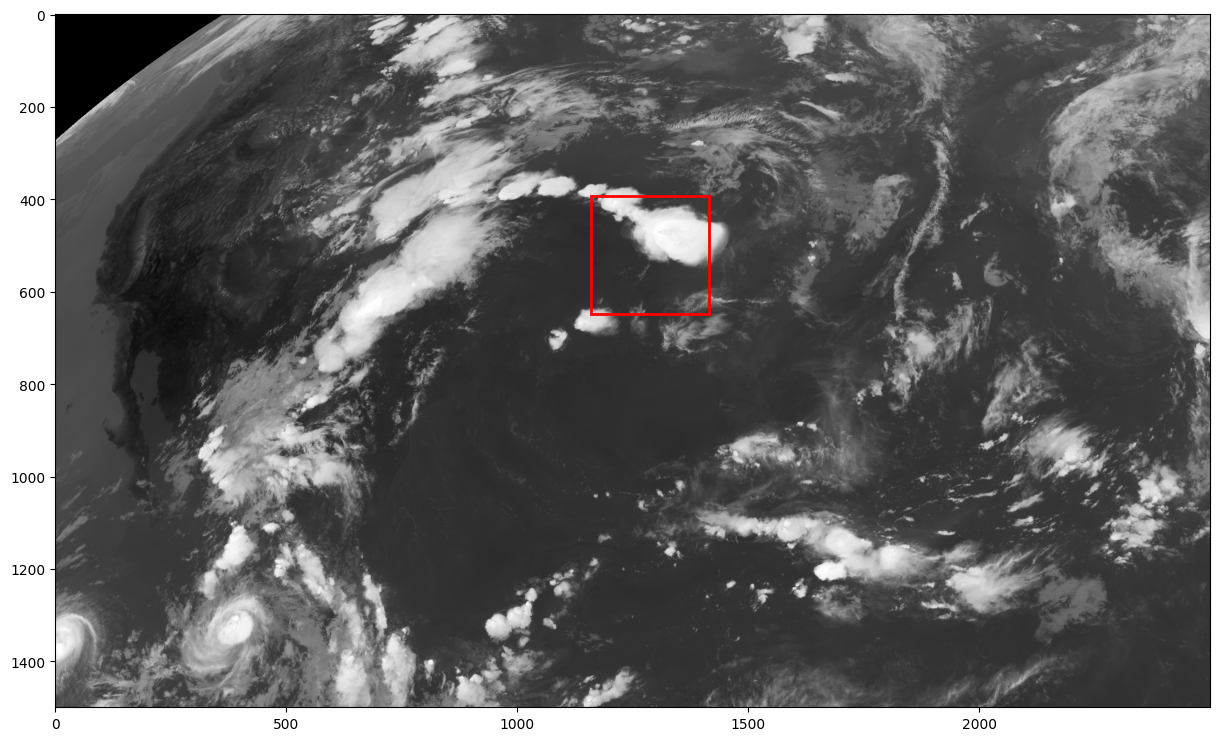

In [4]:
bt = get_bt(files[11])
bt = np.array(bt, dtype=np.float32)

import matplotlib.patches as patches
fig, ax = plt.subplots(figsize=(15, 9))
ax.imshow(bt, cmap='gray_r', vmin=200, vmax=320)
ax.add_patch(patches.Rectangle((col_start, row_start), 256, 256,
             linewidth=2, edgecolor='red', facecolor='none'))
plt.savefig('crop_check.png')